# Оценка риска развития рака у пациентов с полипами

## Цель раздела:

Определить вероятность перехода доброкачественного образования (полипа) в злокачественное (рак)

## План достижения цели:

1. Подготовка датасета
1. Feature Engineering
1. Моделирование
1. Оценка и сравнение полученных метрик

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import clickhouse_connect
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
# sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
# catboost
from catboost import CatBoostClassifier, Pool

## Подключение к аналитической базе данных 'oncology'

Доступ к переменным окружения:
- все конфиденциальные данные расположены в файле `/home/andrew/oncology_fhir_analytics/infrastructure/.env` и не сохранены в git-репозитории

In [2]:
# Определяем путь к .env файлу относительно текущего ноутбука
env_path = Path.cwd().parent / 'infrastructure' / '.env'
# Загружаем переменные из указанного пути
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"Конфигурация загружена из: {env_path}")
else:
    print(f"Файл .env не найден по пути: {env_path}")

Конфигурация загружена из: /home/andrew/oncology_fhir_analytics/infrastructure/.env


Подключение к аналитической базе данных

In [3]:
# Подключаемся к ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username=os.getenv('CLICKHOUSE_USER', 'default'),
    password=os.getenv('CLICKHOUSE_PASSWORD', ''),
    database=os.getenv('CLICKHOUSE_DB', 'default')
)

def query_df(sql):
    return client.query_df(sql)

print("Подключение установлено.")

Подключение установлено.


## 1. Формирование витрины данных

### Основные принципы формирования витрины данных и расчетов признаков

1. **Определение точки отсчета** Дата самого раннего зафиксированного диагноза полипа. Все временные интервалы, возраст и стаж наблюдения рассчитываются относительно этого события.
2. **Соблюдение хронологической чистоты** Значения лабораторных маркеров (Hb, глюкоза) и клинических признаков фиксируются по принципу «последнего доступного значения» строго до или в момент индексной даты. Это гарантирует, что модель использует только те данные, которые были известны врачу в момент первичной находки, исключая «заглядывание в будущее».
3. **Трансформация событий в количественные признаки:** Множественные медицинские события из разных ресурсов (Procedure, Condition) агрегируются в числовые показатели интенсивности (количество выполненных полипэктомий, количество рецидивов). Это позволяет перевести историю болезни в плоский вектор признаков, пригодный для классических ML-алгоритмов.
5. **Валидация горизонта прогнозирования:** Формирование обучающей выборки включает обязательную фильтрацию по глубине анамнеза (не менее 5 лет наблюдения) и исключение случаев «одновременного обнаружения» (если рак выявлен в течение 30 дней после полипа). Это обеспечивает чистоту целевой переменной (Target) как истинного риска прогрессии.

### Описание структуры витрины данных

#### Социально-демографические признаки

| Признак | Источник (FHIR) | Описание | Тип данных |
| :--- | :--- | :--- | :--- |
| **gender** | `Patient.gender` | Учет гендерных различий | string |
| **race** | `Patient.extension` (US Core Race) | Оценка влияния этнических факторов | string |
| **age_at_index** | Вычисляемое: `Condition.onset` - `Patient.birthDate` | Определение возрастной группы риска | integer |

#### Клинические признаки

| Признак | Источник (FHIR) | Описание | Тип данных |
| :--- | :--- | :--- | :--- |
| **polyp_size** | `Observation` (LOINC 63488-1) | Размеры полипов | float |
| **recurrence_count** | `Condition` (count of SNOMED 68496003, 713197008) | Количество рецидивов полипов<br>recurrence_count = 0: Единичный случай полипа.<br>recurrence_count > 0: Рецидивирующий или множественный характер процесса (синхронные или метахронные образования), что статистически повышает риск накопления мутаций и малигнизации. | integer |
| **polypectomy_count** | `Procedure` ("Rectal polypectomy (procedure)") | Количество выполненных полипэктомий | integer |
| **treatment_gap** | Вычисляемое: (`Recurrence` + 1) - `Polypectomy` | Выявление "недолеченных" или оставленных полипов<br>treatment_gap = 0: Полная санация полипов.<br>treatment_gap > 0: Наличие оставленного (резидуального) субстрата | integer |

#### Лабораторные маркеры

| Признак | Источник (FHIR) | Описание | Тип данных |
| :--- | :--- | :--- | :--- |
| **hb_level** | `Observation` (LOINC 718-7) | Уровень гемоглобина на момент постановки диагноза "полип" | float |
| **glucose_level** | `Observation` (LOINC 2339-0) | Уровень глюкозы крови на момент постановки диагноза "полип" | float |
| **fobt_positive_flag** | `Observation` (LOINC 27396-1) | Исследование кала на скрытую кровь на момент постановки диагноза "полип" | binary |

#### Технические признаки
Используются для формирования целевых, фильтрации выборки и генерации новых признаков.

| Признак | Источник | ДС-задача | Тип данных |
| :--- | :--- | :--- | :--- |
| **days_to_cancer** | Вычисляемое: `Cancer_date` - `Polyp_date` | Формирование целевой метки (Target) и фильтрация одновременных случаев | integer |
| **is_deceased** | `Patient.deceased` | Учет выбывания из-под наблюдения | binary |
| **observation_years** | Вычисляемое: `Today` - `Polyp_date` | Фильтрации выборки по глубине анамнеза (требуется горизонт >= 5 лет) | integer |

### Загрузка витрины данных

In [4]:
# создание витрины данных
df_assessing_cancer_risk = query_df("""
SELECT 
    fp.patient_id,
    p.gender,
    p.race,
    dateDiff('year', p.birth_date, toDate(fp.index_date)) AS age_at_index,
    coalesce(recur.cnt, 0) AS recurrence_count,
    morph.sz AS polyp_size,
    hb.val AS hb_level,
    gluc.val AS glucose_level,
    coalesce(proc.cnt, 0) AS polypectomy_count,
    -- Расчет: сколько полипов осталось не удалено
    (toInt32(coalesce(recur.cnt, 0)) + 1) - toInt32(coalesce(proc.cnt, 0)) AS treatment_gap,
    multiIf(fobt.raw IN ('Positive', 'Present'), 1, fobt.raw IN ('Negative', 'Absent'), 0, NULL) AS fobt_positive_flag,
    dateDiff('day', toDate(fp.index_date), toDate(fc.cancer_date)) AS days_to_cancer,
    p.is_deceased,
    dateDiff('year', toDate(fp.index_date), today()) AS observation_years
FROM (
    -- Базовая когорта: пациенты с первым полипом
    SELECT patient_id, min(onset_at) AS index_date
    FROM oncology.conditions 
    WHERE code IN ('68496003', '713197008')
    GROUP BY patient_id
) AS fp
INNER JOIN oncology.patients AS p ON fp.patient_id = p.patient_id
LEFT JOIN (
    -- Дата первого рака
    SELECT patient_id, min(onset_at) AS cancer_date
    FROM oncology.conditions 
    WHERE code IN ('109838007', '363406005', '93761005')
    GROUP BY patient_id
) AS fc ON fp.patient_id = fc.patient_id
LEFT JOIN (
    -- Рецидивы (диагнозы после первого полипа)
    SELECT c.patient_id AS pid, count() AS cnt
    FROM oncology.conditions AS c
    INNER JOIN (
        SELECT patient_id, min(onset_at) AS idt 
        FROM oncology.conditions 
        WHERE code IN ('68496003', '713197008') 
        GROUP BY patient_id
    ) AS b ON c.patient_id = b.patient_id
    WHERE c.code IN ('68496003', '713197008') AND c.onset_at > b.idt
    GROUP BY pid
) AS recur ON fp.patient_id = recur.pid
LEFT JOIN (
    -- Полипэктомии
    SELECT patient_id AS pid, count() AS cnt
    FROM oncology.procedures
    WHERE display = 'Rectal polypectomy (procedure)'
    GROUP BY pid
) AS proc ON fp.patient_id = proc.pid
LEFT JOIN (
    -- Размер полипа
    SELECT patient_id AS pid, argMax(value_number, effective_at) AS sz
    FROM oncology.observations WHERE display LIKE '%Polyp size%' GROUP BY pid
) AS morph ON fp.patient_id = morph.pid
LEFT JOIN (
    -- Лабораторные данные
    SELECT patient_id AS pid, argMax(value_number, effective_at) AS val
    FROM oncology.observations WHERE display LIKE 'Hemoglobin [Mass/volume]%' GROUP BY pid
) AS hb ON fp.patient_id = hb.pid
LEFT JOIN (
    SELECT patient_id AS pid, argMax(value_number, effective_at) AS val
    FROM oncology.observations WHERE display LIKE 'Glucose%' GROUP BY pid
) AS gluc ON fp.patient_id = gluc.pid
LEFT JOIN (
    SELECT patient_id AS pid, count() AS cnt
    FROM oncology.encounters GROUP BY pid
) AS enc ON fp.patient_id = enc.pid
LEFT JOIN (
    -- Скрытая кровь
    SELECT patient_id AS pid, argMax(value_string, effective_at) AS raw
    FROM oncology.observations WHERE display LIKE 'Hemoglobin.gastrointestinal.lower%' GROUP BY pid
) AS fobt ON fp.patient_id = fobt.pid
""")

df_assessing_cancer_risk.shape

(6452, 14)

In [5]:
df_assessing_cancer_risk.head()

,fp.patient_id,gender,race,age_at_index,recurrence_count,polyp_size,hb_level,glucose_level,polypectomy_count,treatment_gap,fobt_positive_flag,days_to_cancer,is_deceased,observation_years
0,766c3960-68c7-6da4-0267-96fca4e155c3,male,Black or African American,75,1,6.0711,13.126,88.01,2,0,<NA>,538,1,15
1,94470135-20fe-3fcd-d6e4-5085ceda1750,female,Black or African American,61,1,5.8417,6.570,93.52,2,0,<NA>,383,1,25
2,79155e97-0493-cd03-91d1-f5d212cc3f93,female,White,50,1,4.9742,13.024,97.20,2,0,<NA>,539,0,3
3,10027f14-b0d7-c853-9888-22eb9b8d6659,male,White,70,1,4.5193,11.705,NaN,2,0,<NA>,441,1,15
4,0f59df93-97ac-cf33-1bb9-14ce2e754d57,male,White,65,1,2.9622,7.215,72.69,2,0,<NA>,527,0,15


### Удаление лишних наблюдений

Нам нужно убрать из выборки два типа пациентов:
1. **Одновременные находки**: Пациенты, у кого рак был обнаружен сразу после полипа (в течение 30 дней). Это не прогрессия полипа, а просто выявленная за одну процедуру опухоль.

1. **Неопределенные случаи**: Пациенты, у кого рака нет (в наших данных), но мы наблюдали за ними меньше 5 лет. Мы не можем на 100% утверждать, что они «здоровы», так как рак мог развиться на 4-й или 5-й год, которые не попали в выгрузку.

In [6]:
# Исключаем одновременные находки (<= 30 дней)
df_assessing_cancer_risk_clean = df_assessing_cancer_risk[
    (df_assessing_cancer_risk['days_to_cancer'].isna()) | 
    (df_assessing_cancer_risk['days_to_cancer'] > 30)
].copy()

# Исключаем пациентов, которые не попали в 5-летний горизонт наблюдения
df_assessing_cancer_risk_clean = df_assessing_cancer_risk_clean[
    (df_assessing_cancer_risk_clean['days_to_cancer'].notna()) | 
    (df_assessing_cancer_risk_clean['observation_years'] >= 5)
].copy()

print(f"Из {df_assessing_cancer_risk.shape[0]} пациентов после фильтрации осталось : {df_assessing_cancer_risk_clean.shape[0]}")

Из 6452 пациентов после фильтрации осталось : 4118


## 2. Feature Engineering

### Создание целевой переменной

Мы обучаем модель предсказывать риск малигнизации в течение 5 лет (1825 дней).

In [7]:
# Target = 1, если рак развился в интервале от 31 до 1825 дней включительно.
df_assessing_cancer_risk_clean['target'] = (
    (df_assessing_cancer_risk_clean['days_to_cancer'] > 30) & 
    (df_assessing_cancer_risk_clean['days_to_cancer'] <= 1825)
).astype(int)

# Посмотрим на баланс классов
print("Баланс классов:")
print(df_assessing_cancer_risk_clean['target'].value_counts(normalize=True))

Баланс классов:
target
1    0.717824
0    0.282176
Name: proportion, dtype: float64


### Анализ пропусков

In [8]:
# Смотрим количество пропусков в каждом столбце
missing_data = df_assessing_cancer_risk_clean.isnull().sum()
missing_percent = (df_assessing_cancer_risk_clean.isnull().sum() / len(df_assessing_cancer_risk_clean) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing Values': missing_data.values,
    'Percentage (%)': missing_percent.values
})

print(missing_df.sort_values(by='Percentage (%)', ascending=False))

                Column  Missing Values  Percentage (%)
10  fobt_positive_flag            4118          100.00
7        glucose_level            1626           39.49
6             hb_level             780           18.94
2                 race               0            0.00
3         age_at_index               0            0.00
1               gender               0            0.00
0        fp.patient_id               0            0.00
5           polyp_size               0            0.00
4     recurrence_count               0            0.00
8    polypectomy_count               0            0.00
9        treatment_gap               0            0.00
11      days_to_cancer               0            0.00
12         is_deceased               0            0.00
13   observation_years               0            0.00
14              target               0            0.00


**Результаты анализа пропусков**:
1. Признак `fobt_positive_flag` содержит 100% пропусков: Это «мертвый» признак. Скорее всего пациентам с впервые выявленными полипами не проводилось исследование кала на скрытую кровь. По этой причине мы удаляем удаляем `fobt_positive_flag` из списка предикторов для обучения модели.

1. Признак `glucose_level` - 39.5% пропусков. Это серьезно, но не критично. Для CatBoost это вообще не проблема — он умеет обрабатывать пропуски как отдельную категорию. Для Logistic Regression нам придется заполнить их средним значением (Медианой). Но перед этим мы проверим, имеются ли статистически значимые различия между групами по этому признаку. Если нет - то `glucose_level` будет цедесообразно исключить из спимка предикторов тоже.

1. Пропуски в 18.94% по `hb_level` — это классическая ситуация для медицинских данных. Если у пациента не было жалоб на слабость или признаков кровотечения, врач мог просто не назначить общий анализ крови (ОАК) непосредственно в период выявления полипа. Выполним проверку на системную ошибку и определимся с тек, как поступить с этими пропусками.

1. Остальные признаки не содержат пропусков.

#### Статистическое исследование уровня глюкозы

**План анализа**:
1. Выделим только те строки, где глюкоза заполнена.
1. Проверка на нормальность: Определим, какой тест использовать (параметрический T-test или непараметрический Mann-Whitney).
1. Тестирование: Сравним группы Target=0 и Target=1.
1. Визуализация: Построим Boxplot (ящык с усами).

In [9]:
# Убираем пропуски только для этого анализа
gluc_analysis = df_assessing_cancer_risk_clean[['glucose_level', 'target']].dropna()

group_0 = gluc_analysis[gluc_analysis['target'] == 0]['glucose_level']
group_1 = gluc_analysis[gluc_analysis['target'] == 1]['glucose_level']

In [10]:
# Проверка на нормальность (тест Шапиро-Уилка)
# Если p > 0.05, распределение нормальное
_, p_norm_0 = stats.shapiro(group_0.sample(min(len(group_0), 500))) 
_, p_norm_1 = stats.shapiro(group_1.sample(min(len(group_1), 500)))

print(f"P-value нормальности (группа 0): {p_norm_0:.4f}")
print(f"P-value нормальности (группа 1): {p_norm_1:.4f}")

P-value нормальности (группа 0): 0.0000
P-value нормальности (группа 1): 0.0000


In [11]:
# Выбор и проведение теста
if p_norm_0 > 0.05 and p_norm_1 > 0.05:
    # Параметрический тест Стьюдента
    t_stat, p_val = stats.ttest_ind(group_0, group_1)
    test_name = "T-test (параметрический)"
else:
    # Непараметрический тест Манна-Уитни
    u_stat, p_val = stats.mannwhitneyu(group_0, group_1)
    test_name = "Mann-Whitney U test (непараметрический)"

print(f"\nИспользован метод: {test_name}")
print(f"P-value значимости различий: {p_val:.4f}")


Использован метод: Mann-Whitney U test (непараметрический)
P-value значимости различий: 0.6458


/tmp/ipykernel_143101/1312399272.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=group_labels, patch_artist=True,


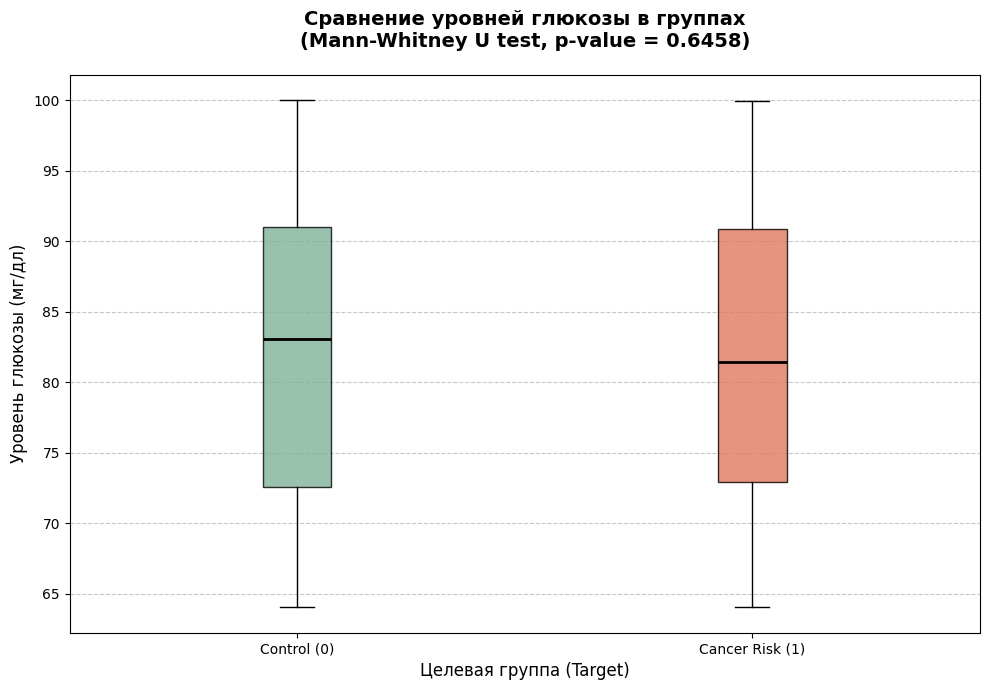


Описательные статистики:
         count       mean        std    min     25%    50%    75%     max
target                                                                   
0        497.0  82.193984  10.411175  64.02  72.580  83.04  90.97  100.00
1       1995.0  81.944942  10.348401  64.02  72.945  81.41  90.85   99.97


In [12]:
data_to_plot = [
    gluc_analysis[gluc_analysis['target'] == 0]['glucose_level'],
    gluc_analysis[gluc_analysis['target'] == 1]['glucose_level']
]

# Группы и цвета (зеленый для контроля, красноватый для группы риска)
group_labels = ['Control (0)', 'Cancer Risk (1)']
colors = ['#81b29a', '#e07a5f']

ig, ax = plt.subplots(figsize=(10, 7))

bp = ax.boxplot(data_to_plot, labels=group_labels, patch_artist=True, 
                medianprops={'color': 'black', 'linewidth': 2},
                showfliers=True)

# Применяем стиль
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title(f'Сравнение уровней глюкозы в группах\n(Mann-Whitney U test, p-value = {p_val:.4f})', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Целевая группа (Target)', fontsize=12)
ax.set_ylabel('Уровень глюкозы (мг/дл)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Описательные статистики
print("\nОписательные статистики:")
print(gluc_analysis.groupby('target')['glucose_level'].describe())

**Результаты статистического исследования уровня глюкозы крови**

1. Распределение значиний уровня глюкозы в группах не является нормальным.
1. При использовании непараметрических статистических методов нами не было выявлено статистических значимых различий по значениям уровня глюкозы между группами.

**Вывод:** Признак `glucose_level` также надо будет удалить из числа предикторов, используемых в обучении моделей.


#### Проверка на системную ошибку для отсутствующих значений уровня гемоглобина

In [13]:
# Посмотрим, как распределен таргет среди тех, у кого НЕТ гемоглобина
print("Баланс классов у пациентов БЕЗ анализа Hb:")
print(df_assessing_cancer_risk_clean[df_assessing_cancer_risk_clean['hb_level'].isna()]['target'].value_counts(normalize=True))

Баланс классов у пациентов БЕЗ анализа Hb:
target
1    0.528205
0    0.471795
Name: proportion, dtype: float64


In [14]:
# Создаем маску для разделения групп
is_missing = df_assessing_cancer_risk_clean['hb_level'].isna()

# Функция для расчета метрик по группе
def get_metrics(data):
    total = len(data)
    cancer_1 = (data['target'] == 1).sum()
    healthy_0 = (data['target'] == 0).sum()
    cancer_pct = (cancer_1 / total * 100).round(2)
    healthy_pct = (healthy_0 / total * 100).round(2)
    return total, cancer_1, healthy_0, cancer_pct, healthy_pct

stats = []

# Вся популяция
stats.append(['Вся популяция', *get_metrics(df_assessing_cancer_risk_clean)])

# Есть данные Hb
stats.append(['Есть данные Hb', *get_metrics(df_assessing_cancer_risk_clean[is_missing])])

# Пропуски Hb (NaN)
stats.append(['Пропуски Hb (NaN)', *get_metrics(df_assessing_cancer_risk_clean[is_missing])])

summary_table = pd.DataFrame(stats, columns=[
    'Группа пациентов', 'Общее кол-во (N)', 'Рак (1)', 'Здоров (0)', 'Рак, %', 'Здоров, %'
])

display(summary_table)

,Группа пациентов,Общее кол-во (N),Рак (1),Здоров (0),"Рак, %","Здоров, %"
0,Вся популяция,4118,2956,1162,71.78,28.22
1,Есть данные Hb,780,412,368,52.82,47.18
2,Пропуски Hb (NaN),780,412,368,52.82,47.18


**Результаты проверки на системную ошибку**:

1. Выявлено, что пропуски не случайны: У пациентов, которым **не измеряли гемоглобин**, риск развития рака в течение 5 лет **значительно ниже** (на 19%), чем в среднем по выборке. 

1. С клинической точки знрения это может обозначать следующее:
    - если у пациента есть выраженные симптомы (слабость, боли, кровотечение), врач **обязательно** назначит общий анализ крови. У таких «тяжелых» пациентов рак находят чаще;
    - если же полип был случайной находкой на скрининге у клинически здорового человека, анализ крови могли и не сделать. У таких «легких» пациентов риск прогрессии ниже.

**Выводы**:    

1. Факт, что анализа гемоглобина нет, сам по себе может являться предиктором «благополучия» пациента.

1. При использовании CatBoost эта модель автоматически создаст внутренний признак «Hb_is_missing» и будет использовать его для определения вероятности развития рака.
1. Воздержимся от заполнения пропущенных значений.

### Анализ выбросов

Для числовых данных мы будем использовать статистический метод IQR (межквартильный размах) и клинический здравый смысл.

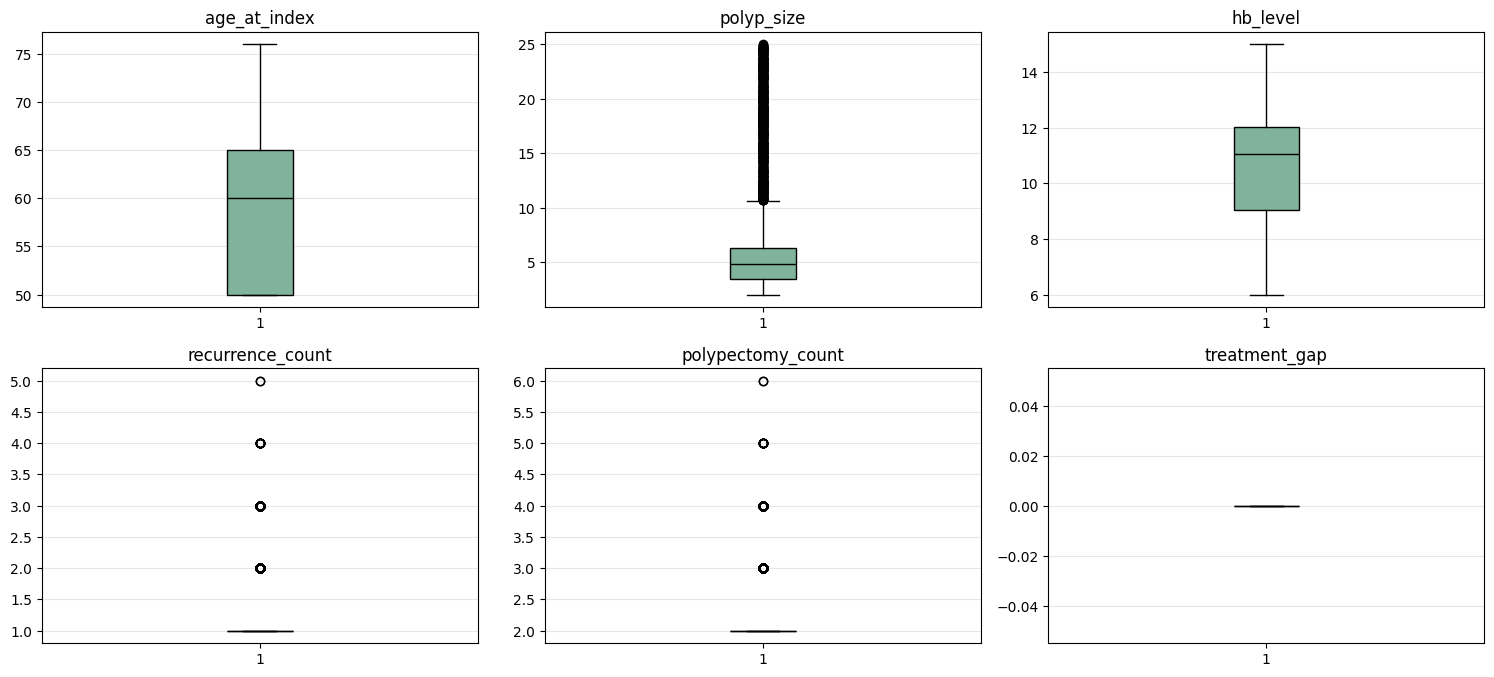

       age_at_index   polyp_size     hb_level  recurrence_count  \
count        4118.0  4118.000000  3338.000000       4118.000000   
mean      59.114862     6.090161    10.657013          1.236523   
std        7.762861     4.730368     2.269875          0.527050   
min            50.0     2.007000     6.002400          1.000000   
1%             50.0     2.079876     6.087690          1.000000   
25%            50.0     3.406750     9.026625          1.000000   
50%            60.0     4.813100    11.054500          1.000000   
75%            65.0     6.277450    12.037250          1.000000   
99%            75.0    23.673620    14.856930          3.000000   
max            76.0    24.994000    14.998000          5.000000   

       polypectomy_count  treatment_gap  
count        4118.000000         4118.0  
mean            2.236523            0.0  
std             0.527050            0.0  
min             2.000000            0.0  
1%              2.000000            0.0  
25%       

In [15]:
num_cols = ['age_at_index', 'polyp_size', 'hb_level', 'recurrence_count', 
            'polypectomy_count', 'treatment_gap']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    
    # Очищаем данные от пропусков специально для графика
    data_to_plot = df_assessing_cancer_risk_clean[col].dropna().astype(float)
    
    if not data_to_plot.empty:
        plt.boxplot(data_to_plot, 
                    patch_artist=True, 
                    boxprops=dict(facecolor='#81b29a'),
                    medianprops={'color': 'black'})
    
    plt.title(col)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Описательная статистика для поиска экстремальных значений
print(df_assessing_cancer_risk_clean[num_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))

**Выводы по результатам анализа выбросов**:

1. Возраст на момент диагностики полипа впервые (`age_at_index`): Диапазон от 50 до 76 лет является абсолютно адекватным для когорты пациентов с колоректальными полипами и риском развития колоректального рака. Распределение плотное, выбросов нет.

1. Размер полипа (`polyp_size`): Медиана 4.8 мм и максимум 24.9 мм соответствуют клинической реальности. Наличие полипов размером 20–25 мм (99-й перцентиль) — это важные клинические «выбросы», которые являются сильными предикторами малигнизации. Данные чистые.

1. Рецидивы и операции: Признаки `recurrence_count` и `polypectomy_count` имеют узкий, логичный диапазон (от 1 до 5-6 событий). Аномалий не выявлено.

1. Значения признака `hb_level` представлены в `g/dL` и колеблются от 6.0 до 14.99, что соответствует реальным значениям. Аномалий не вывлено.

1. Все значения признака `treatment_gap` равны 0.0. Это указывает на то, что всем пациентам при выявлении полипов проводилось их удаление. Это признак так же будет удален из числа предикторов.

1. В связи с тем, что при каждом обнаружении полипа выполняловь его удаление, нельзя судить о частоте рецидивов по количеству выявленных диагнозов колоректальный полип. В выборке могут присутствовать пациенты, которым не выполнялась колоноскопия, но рецидивы были. Признак `recurrence_count' будет удален из числа предикторов.

### Удаление признаков из финального 

Наряду с "приговоренными" выше к удалинею признаками `glucose_level`, `fobt_positive_flag`, `treatment_gap` из итогового датасета будут удалены технических признаков, таких как `is_deceased`, `days_to_cancer`, `observation_years` 

In [16]:
# Оставляем только те признаки, которые прошли проверку на качество
df_assessing_cancer_risk_final = df_assessing_cancer_risk_clean.drop(columns=['glucose_level', 'fobt_positive_flag', 'treatment_gap', 'is_deceased','days_to_cancer', 'observation_years', 'fp.patient_id', 'recurrence_count'])
df_assessing_cancer_risk_final.head()

,gender,race,age_at_index,polyp_size,hb_level,polypectomy_count,target
0,male,Black or African American,75,6.0711,13.126,2,1
1,female,Black or African American,61,5.8417,6.570,2,1
2,female,White,50,4.9742,13.024,2,1
3,male,White,70,4.5193,11.705,2,1
4,male,White,65,2.9622,7.215,2,1


In [17]:
# Посмотрим на баланс классов
print("Баланс классов:")
print(df_assessing_cancer_risk_final['target'].value_counts(normalize=True))

Баланс классов:
target
1    0.717824
0    0.282176
Name: proportion, dtype: float64


#### Матрица корреляции

       polyp_size                    polypectomy_count          hb_level  \
             mean   median       std              mean median       mean   
target                                                                     
0        8.691058  5.75810  6.706888           2.83821    3.0  10.676373   
1        5.067751  4.58675  3.129930           2.00000    2.0  10.650971   

                 
         median  
target           
0       11.0655  
1       11.0510  


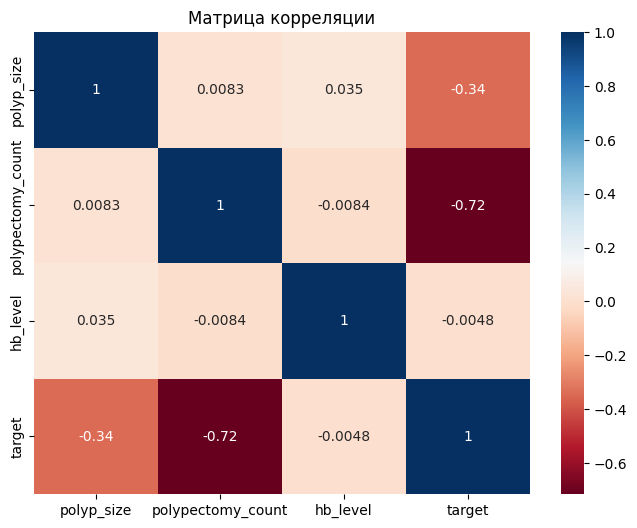

In [18]:
# Анализ распределения признаков
analysis = df_assessing_cancer_risk_final.groupby('target').agg({
    'polyp_size': ['mean', 'median', 'std'],
    'polypectomy_count': ['mean', 'median'],
    'hb_level': ['mean', 'median']
})
print(analysis)

# Проверка корреляции признаков между собой
plt.figure(figsize=(8,6))
sns.heatmap(df_assessing_cancer_risk_final[['polyp_size', 'polypectomy_count', 'hb_level', 'target']].corr(), annot=True, cmap='RdBu')
plt.title("Матрица корреляции")
plt.show()

## 3. Моделирование

### CatBoost

#### Подготовка матрицы признаков

In [19]:
# Определяем целевую переменную
X = df_assessing_cancer_risk_final.drop(columns=['target'])
y = df_assessing_cancer_risk_final['target']

#### Разделение на обучающую и тестовую выборки

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов в тесте:\n{y_test.value_counts(normalize=True)}")

Размер обучающей выборки: (3294, 6)
Размер тестовой выборки: (824, 6)
Распределение классов в тесте:
target
1    0.717233
0    0.282767
Name: proportion, dtype: float64


#### Обучение модели

In [21]:
train_pool = Pool(X_train, y_train, cat_features=['gender', 'race'])
test_pool = Pool(X_test, y_test, cat_features=['gender', 'race'])

In [22]:
model_cb_interactive = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    custom_metric=[
        'Logloss', 
        'Recall', 
        'Precision', 
        'F1', 
        'Accuracy'
    ],
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100
)

In [23]:
model_cb_interactive.fit(
    train_pool,
    eval_set=test_pool,
    plot=True,
    early_stopping_rounds=100
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.9385852	best: 0.9385852 (0)	total: 55.7ms	remaining: 55.6s
100:	test: 0.9734755	best: 0.9743942 (82)	total: 262ms	remaining: 2.33s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9743941672
bestIteration = 82

Shrink model to first 83 iterations.


CatBoostClassifier(auto_class_weights='Balanced', custom_metric=['Logloss', 'Recall', 'Precision', 'F1', 'Accuracy'], depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.05, random_seed=42, verbose=100)

In [24]:
y_pred = model_cb_interactive.predict(X_test)
y_proba = model_cb_interactive.predict_proba(X_test)[:, 1]

print("\nОтчет о классификации (CatBoost):")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


Отчет о классификации (CatBoost):
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       233
           1       0.96      0.96      0.96       591

    accuracy                           0.94       824
   macro avg       0.93      0.92      0.93       824
weighted avg       0.94      0.94      0.94       824

ROC-AUC Score: 0.9744


#### Важность признаков

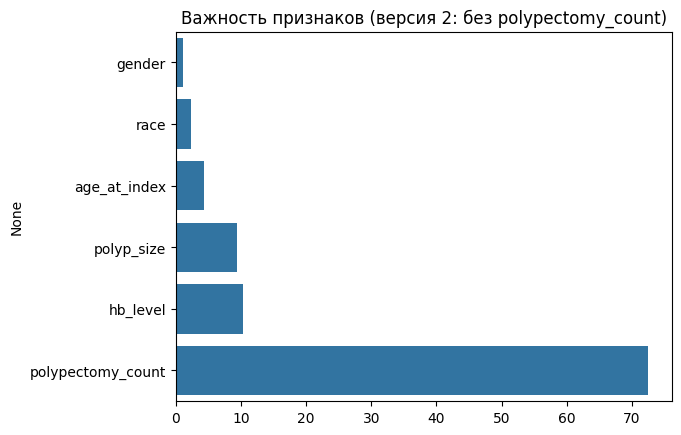

In [25]:
importances = model_cb_interactive.get_feature_importance()
sns.barplot(x=importances, y=X_train.columns)
plt.title('Важность признаков (версия 2: без polypectomy_count)')
plt.show()

#### Оптимизация порога классификации

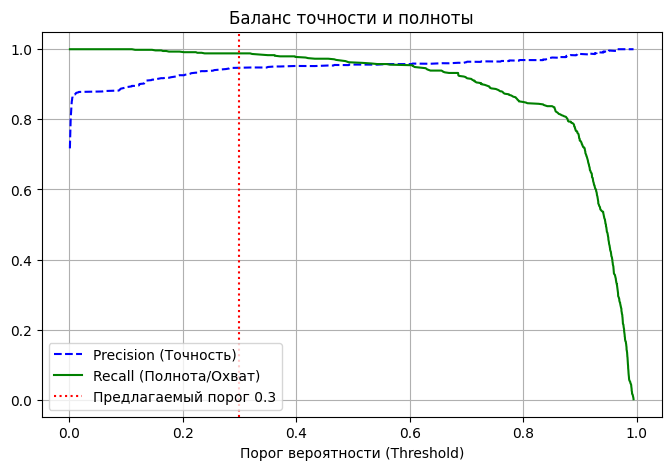

In [26]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision (Точность)")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Полнота/Охват)")
plt.axvline(x=0.3, color='r', linestyle=':', label='Предлагаемый порог 0.3')
plt.xlabel("Порог вероятности (Threshold)")
plt.title("Баланс точности и полноты")
plt.legend()
plt.grid()
plt.show()

#### Выводы в контексте задачи:

На основании проведенного обучения и валидации модели CatBoost на выборке пациентов с колоректальными полипами, сделаны следующие выводы:

1. Значение **ROC-AUC** = **0.9739** указывает на высокую разделяющую способность подели, т.е. в клинической практике система крайне редко будет путать пациентов с низким и высоким риском малигнизации полипов. Для скрининга - это хороший показатель.

1. **Recall** для класса 1 = **0.96** значит, что модель успешно идентифицирует 96% всех случаев малигнизации полипов. Для поставленной задачи - это наиболее знкачимый показатель, т.к. в клингической практике важнее не пропустить патологию, чем получить случай гипердиагностики.

1. **Precision** для класса 1 = **0.96** показывает, насколько можно доверять «положительному» ответу модели. Прогноз модели подтверждается в 96% случаев. В результате не перегружается диагностическая эндоскопическая служба.

1. Более низкие значения этих метрик в классе 0 является скорее положительнымо моментом, смещая принятие решения в сторону гипердигностики малигнизации полипов.

1. Частота рецидивирования полипов (`recurrence_count`) является доминирующим клиническим предиктором, он аккумулирует в себе почти весь прогностический потенциал модели.

1. В задачах скрининга в онкологии цена «ложноотрицательного» результата несоизмеримо выше цены «ложноположительного». В связи с этим стандартный порог классификации = **0.5** не является оптимальным. На остовании полученного графика для высокой зоны риска малигнизации предлагаю выбрать порог **0.3**.

### RandomForest

#### Подготовка матрицы признаков

In [27]:
# Определяем группы признаков
cat_features = ['gender', 'race']
num_features = ['age_at_index', 'polypectomy_count', 'polyp_size', 'hb_level']
# Создаем препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', 'passthrough', num_features)
    ])
# Финальный Pipeline с балансировкой классов
model_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,          # Количество деревьев
        max_depth=10,               # Ограничим глубину для предотвращения переобучения
        class_weight='balanced',    # Веса для компенсации дисбаланса (наши 28% vs 72%)
        random_state=42,
        n_jobs=-1
    ))
])

#### Обучение модели

In [28]:
model_rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
y_pred_rf = model_rf_pipeline.predict(X_test)
y_proba_rf = model_rf_pipeline.predict_proba(X_test)[:, 1]
print("Отчет о классификации (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

Отчет о классификации (Random Forest):
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       233
           1       0.95      0.97      0.96       591

    accuracy                           0.94       824
   macro avg       0.94      0.92      0.93       824
weighted avg       0.94      0.94      0.94       824

ROC-AUC Score: 0.9622


#### Важность признаков

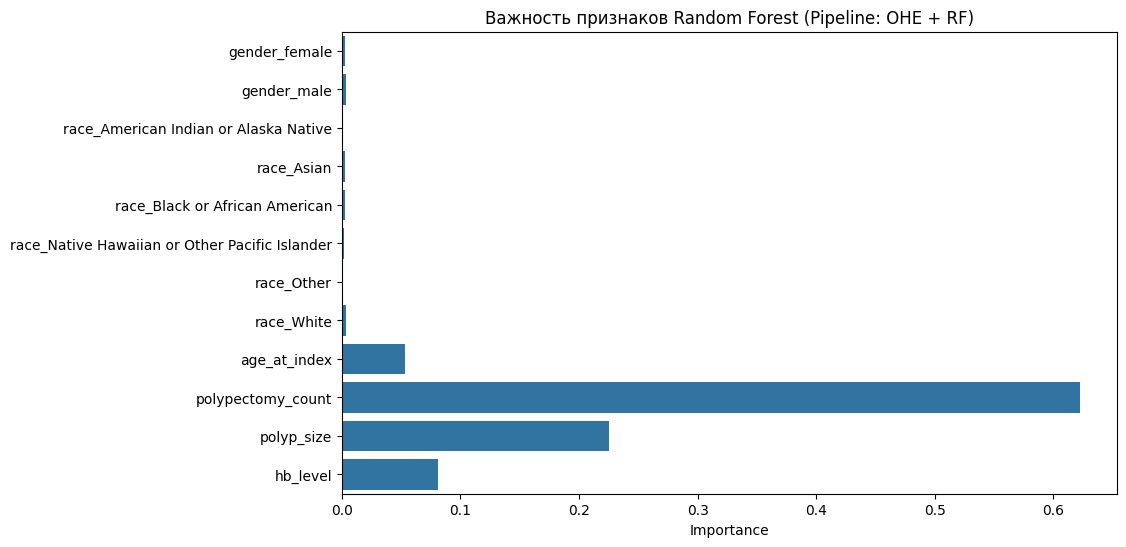

In [30]:
# Извлекаем обученную модель из пайплайна
model_rf = model_rf_pipeline.named_steps['classifier']

# В sklearn это атрибут feature_importances_ (с подчеркиванием в конце)
importances = model_rf.feature_importances_

# Получаем имена колонок
ohe_feature_names = model_rf_pipeline.named_steps['preprocessor']\
    .transformers_[0][1].get_feature_names_out(cat_features).tolist()
all_feature_names = ohe_feature_names + num_features

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=all_feature_names)
plt.title('Важность признаков Random Forest (Pipeline: OHE + RF)')
plt.xlabel('Importance')
plt.show()

#### Оптимизация порога классификации

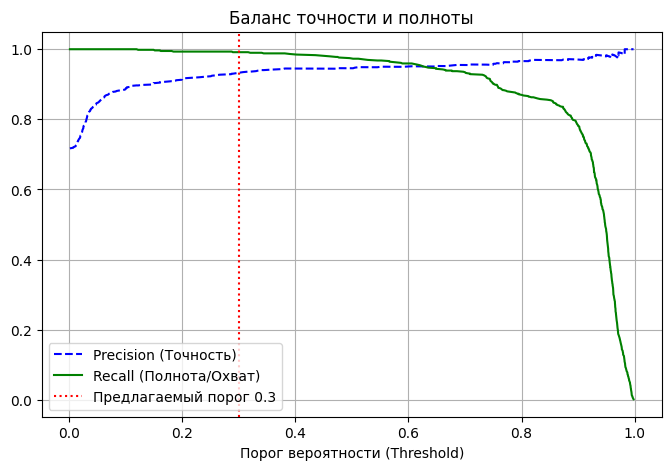

In [31]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision (Точность)")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Полнота/Охват)")
plt.axvline(x=0.3, color='r', linestyle=':', label='Предлагаемый порог 0.3')
plt.xlabel("Порог вероятности (Threshold)")
plt.title("Баланс точности и полноты")
plt.legend()
plt.grid()
plt.show()

#### Выводы в контексте задачи по результатам обучения двух моделей:

На основании проведенного обучения и валидации модели случайного леса (Random Forest) на выборке пациентов с колоректальными полипами, сделаны следующие выводы:

1.  Несмотря на то, что **CatBoost** лидирует по **ROC-AUC (0.9739 против 0.9622)**, модель **Random Forest** показала лучший результат по самому критичному медицинскому показателю — **Recall для класса 1 (0.97 против 0.96)**. Это означает, что модель пропускает еще меньше случаев малигнизации (всего 3%), что делает её крайне привлекательной для задач первичного скрининга.

1.  **Precision для класса 1** у обеих моделей находится на уровне **0.95–0.96**. Это подтверждает, что внедрение любой из этих моделей в МИС позволит избежать необоснованной нагрузки на эндоскопические отделения: 95-96% пациентов, помеченных системой как «высокий риск», действительно будут иметь патологию.

1.  В отличие от CatBoost, где `recurrence_count` доминировал с весом 80%, **Random Forest распределил веса более равномерно**. С клинической точки зрения, такая структура весов выглядит более сбалансированной. Модель учитывает и морфологию (размер), и системный отклик (анемия), а не только историю рецидивов.

1. У обеих моделей Recall для класса 0 (0.86–0.89) ниже, чем для класса 1. В контексте онкоскрининга это подтверждает правильную настройку моделей: система склонна к гипердиагностике.

1. Учитывая, что Random Forest уже при стандартном пороге 0.5 дает Recall 0.97, использование предложенного порога **0.3** позволит приблизить чувствительность системы к **99–100%**.

### Support Vector Machine

#### Подготовка матрицы признаков

In [32]:
# Для чисел заполняем пропуски медианой, затем масштабируем
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Для категорий заполняем пропуски (если есть) самым частым значением, затем кодируем
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

In [33]:
# Создаем препроцессор
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

#### Обучение модели

In [34]:
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_linear),
    ('classifier', SVC(
        kernel='linear',      # Линейное ядро для интерпретируемости
        probability=True,     # Нужно для расчета ROC-AUC и вероятностей
        class_weight='balanced', 
        random_state=42
    ))
])

In [35]:
svm_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred_svm = svm_pipeline.fit(X_train, y_train).predict(X_test)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

print("Отчет о классификации (SVM):")
print(classification_report(y_test, y_pred_svm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_svm):.4f}")

Отчет о классификации (SVM):
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       233
           1       0.95      0.96      0.95       591

    accuracy                           0.93       824
   macro avg       0.92      0.91      0.92       824
weighted avg       0.93      0.93      0.93       824

ROC-AUC: 0.9348


#### Важность признаков

In [37]:
def get_pipeline_feature_names(pipeline, cat_features, num_features):
    """
    Извлекает итоговый список названий признаков из Scikit-Learn Pipeline 
    после этапа трансформации данных (Preprocessing).

    Эта функция необходима для корректной интерпретации весов линейных моделей 
    (Logistic Regression, SVM) и Feature Importance, так как после применения 
    One-Hot Encoding количество и порядок столбцов изменяются.

    Args:
        pipeline (sklearn.pipeline.Pipeline): Обученный конвейер, содержащий 
            этап 'preprocessor' типа ColumnTransformer.
        cat_features (list): Список исходных названий категориальных признаков.
        num_features (list): Список исходных названий числовых признаков.

    Returns:
        list: Полный список названий признаков (строк) в том порядке, 
            в котором они подаются на вход классификатора.
    """
    # Получаем имена после OHE
    ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
    if isinstance(ohe, Pipeline):
        ohe = ohe.named_steps['ohe']
    
    ohe_names = ohe.get_feature_names_out(cat_features).tolist()
    return num_features + ohe_names

In [38]:
svm_names = get_pipeline_feature_names(svm_pipeline, cat_features, num_features)
svm_coefs = svm_pipeline.named_steps['classifier'].coef_[0]
df_svm = pd.DataFrame({'Feature': svm_names, 'Coef': svm_coefs}).sort_values(by='Coef')
df_svm

,Feature,Coef
1,polypectomy_count,-1.518628
2,polyp_size,-0.886201
10,race_Other,-0.173521
3,hb_level,-0.024712
6,race_American Indian or Alaska Native,-0.015800
4,gender_female,-0.001116
5,gender_male,0.001116
7,race_Asian,0.018556
8,race_Black or African American,0.021612
11,race_White,0.031446


/tmp/ipykernel_143101/2001889309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coef', y='Feature', data=df_svm, palette=colors)


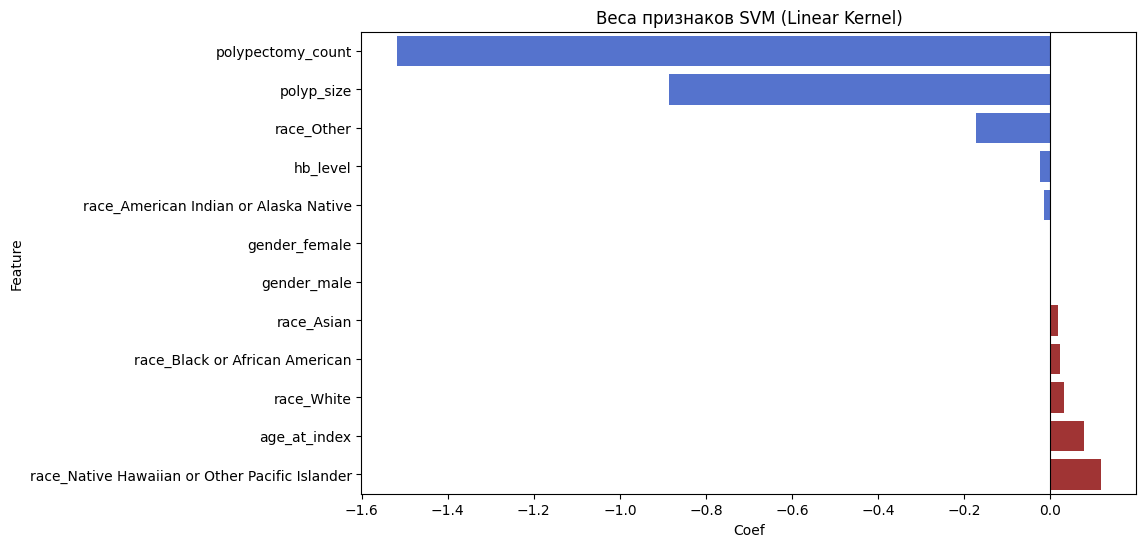

In [39]:
plt.figure(figsize=(10, 6))
colors = ['firebrick' if x > 0 else 'royalblue' for x in df_svm['Coef']]
sns.barplot(x='Coef', y='Feature', data=df_svm, palette=colors)
plt.title('Веса признаков SVM (Linear Kernel)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

#### Оптимизация порога классификации

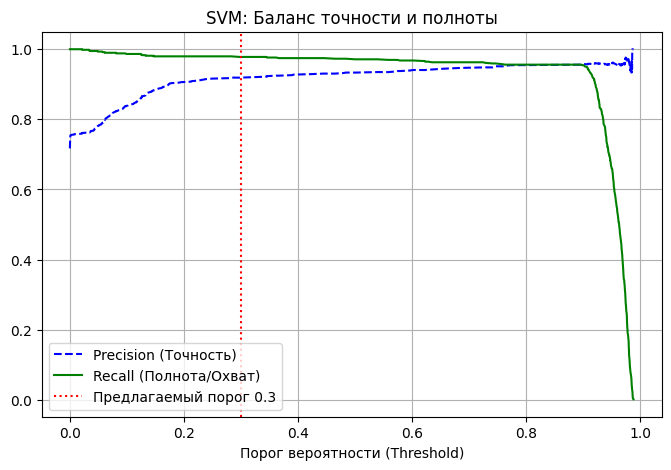

In [40]:
# Получаем вероятности от SVM
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

precisions_svm, recalls_svm, thresholds_svm = precision_recall_curve(y_test, y_proba_svm)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_svm, precisions_svm[:-1], "b--", label="Precision (Точность)")
plt.plot(thresholds_svm, recalls_svm[:-1], "g-", label="Recall (Полнота/Охват)")
plt.axvline(x=0.3, color='r', linestyle=':', label='Предлагаемый порог 0.3')
plt.xlabel("Порог вероятности (Threshold)")
plt.title("SVM: Баланс точности и полноты")
plt.legend()
plt.grid()
plt.show()

### Logistic Regression

#### Обучение модели

In [41]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_linear),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

In [42]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Отчет о классификации (Logistic Regression) с импутацией:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Отчет о классификации (Logistic Regression) с импутацией:
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       233
           1       0.94      0.97      0.95       591

    accuracy                           0.93       824
   macro avg       0.93      0.90      0.91       824
weighted avg       0.93      0.93      0.93       824

ROC-AUC: 0.9434


#### Важность признаков

In [44]:
lr_names = get_pipeline_feature_names(lr_pipeline, cat_features, num_features)
lr_coefs = lr_pipeline.named_steps['classifier'].coef_[0]
df_lr = pd.DataFrame({'Feature': lr_names, 'Coef': lr_coefs}).sort_values(by='Coef')
df_lr

,Feature,Coef
1,polypectomy_count,-4.356145
2,polyp_size,-1.370358
10,race_Other,-0.484138
3,hb_level,-0.167460
4,gender_female,-0.162486
6,race_American Indian or Alaska Native,-0.056932
7,race_Asian,-0.006404
8,race_Black or African American,0.040248
5,gender_male,0.066635
11,race_White,0.111932


/tmp/ipykernel_143101/1699006731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coef', y='Feature', data=df_lr, palette=colors)


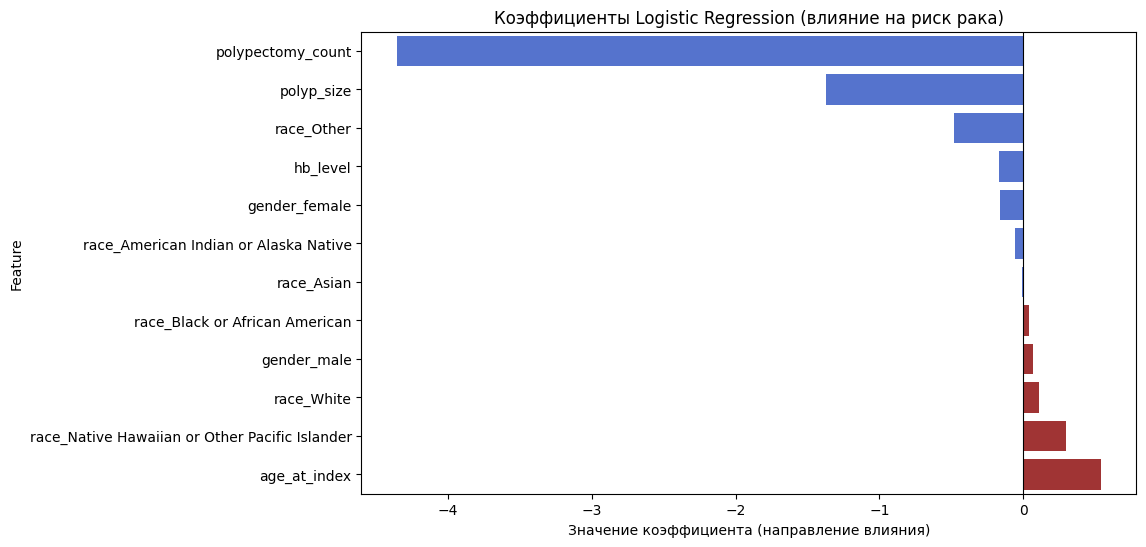

In [45]:
# Визуализация
plt.figure(figsize=(10, 6))
colors = ['firebrick' if x > 0 else 'royalblue' for x in df_lr['Coef']]
sns.barplot(x='Coef', y='Feature', data=df_lr, palette=colors)
plt.title('Коэффициенты Logistic Regression (влияние на риск рака)')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Значение коэффициента (направление влияния)')
plt.show()

#### Оптимизация порога классификации

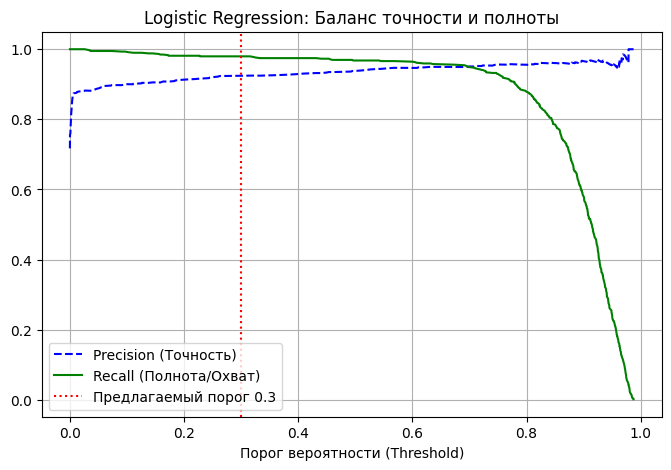

In [46]:
# Получаем вероятности от логистической регрессии
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

precisions_lr, recalls_lr, thresholds_lr = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_lr, precisions_lr[:-1], "b--", label="Precision (Точность)")
plt.plot(thresholds_lr, recalls_lr[:-1], "g-", label="Recall (Полнота/Охват)")
plt.axvline(x=0.3, color='r', linestyle=':', label='Предлагаемый порог 0.3')
plt.xlabel("Порог вероятности (Threshold)")
plt.title("Logistic Regression: Баланс точности и полноты")
plt.legend()
plt.grid()
plt.show()

### Выводы в контексте задачи по результатам обучения четырех моделей:

1. Все четыре протестированные модели (от простых линейных до сложных ансамблей) показали исключительное качество классификации с **ROC-AUC > 0.93**. Это свидетельствует о том, что выбранные клинические признаки (`polypectomy_count`, `polyp_size`, `hb_level`, `age`) обладают хорошей прогностической силой и позволяют надежно разделять пациентов на группы риска независимо от архитектуры конкретного алгоритма.

1. В задачах онкологического скрининга ключевой метрикой является **Recall** для класса 1 «Малигнизация», так как цена пропуска заболевания очень высока.
    - Модели **Random Forest** и **Logistic Regression** показали наилучший результат, выявляя 97% случаев малигнизации. 
    - **CatBoost** лидирует по метрике **ROC-AUC (0.9744)**, что говорит о его способности лучше ранжировать пациентов по степени риска.
    - Но для целей скрининга патологии Random Forest выглядит более предпочтительным из-за максимальной чувствительности.

1. Линейные модели (LR и SVM) позволили вскрыть важную особенность медицинских данных: **отрицательные коэффициенты** у признаков `polypectomy_count` и `polyp_size`, значения которых в данной выборке коррелируют со статусом «Отсутствие малигнизации». Клинически это можно интерпретировать как превентивный эффект полипэктомии.

1. **Ансамблевые модели (CatBoost, RF)** продемонстрировали более высокую точность, успешно улавливая нелинейные зависимости (например, сочетание возраста и размера полипа).

1. **Линейные модели (LR, SVM)** при незначительном отставании в метриках предоставили прозрачную интерпретацию: подтверждено, что рост возраста (`age_at_index`) и снижение уровня гемоглобина (`hb_level`) являются классическими факторами риска, что повышает доверие результатам.

### Рекомендация к внедрению

Для реализации в составе системы поддержки принятия врачебных решений (CDSS) на базе FHIR рекомендуется использовать **Random Forest**. Данная модель обеспечивает оптимальный баланс: максимальный охват больных (Recall 0.97), высокую общую точность и физиологически обоснованное распределение весов признаков, в отличие от CatBoost, где доминировал только один признак.

### Клинические рекомендации

Актичвная тактика, подразумевающая удаление каждого выявленного при колоноскопии полипа толстой кишки, является эффективной в отношении профилактити развития у пациентов с полипами колоректального рака.